In [340]:
import pandas as pd

big_nss = pd.read_csv('big_nss.csv', index_col=0)
big_nss.head()


C:\Users\Geraden\AppData\Local\Temp\ipykernel_304\865843749.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  big_nss = pd.read_csv('big_nss.csv', index_col=0)


,RecordID,EventTimeStamp,EquipmentID,EngineOilPressure,EngineOilTemperature,DistanceLtd,FuelLtd,EngineTimeLtd,Derate
0,1211417,2000-03-18 19:14:10,2015,25.52,190.85,274765.4,37866.421934,5673.1,False
1,1211418,2000-03-18 19:14:10,2015,25.52,190.85,274765.4,37866.421934,5673.1,False
2,1211419,2000-03-18 19:20:47,2015,NaN,NaN,NaN,NaN,NaN,False
3,1211420,2000-03-18 19:20:47,2015,NaN,NaN,NaN,NaN,NaN,False
4,1211422,2000-03-19 02:59:58,1849,NaN,NaN,NaN,NaN,NaN,False


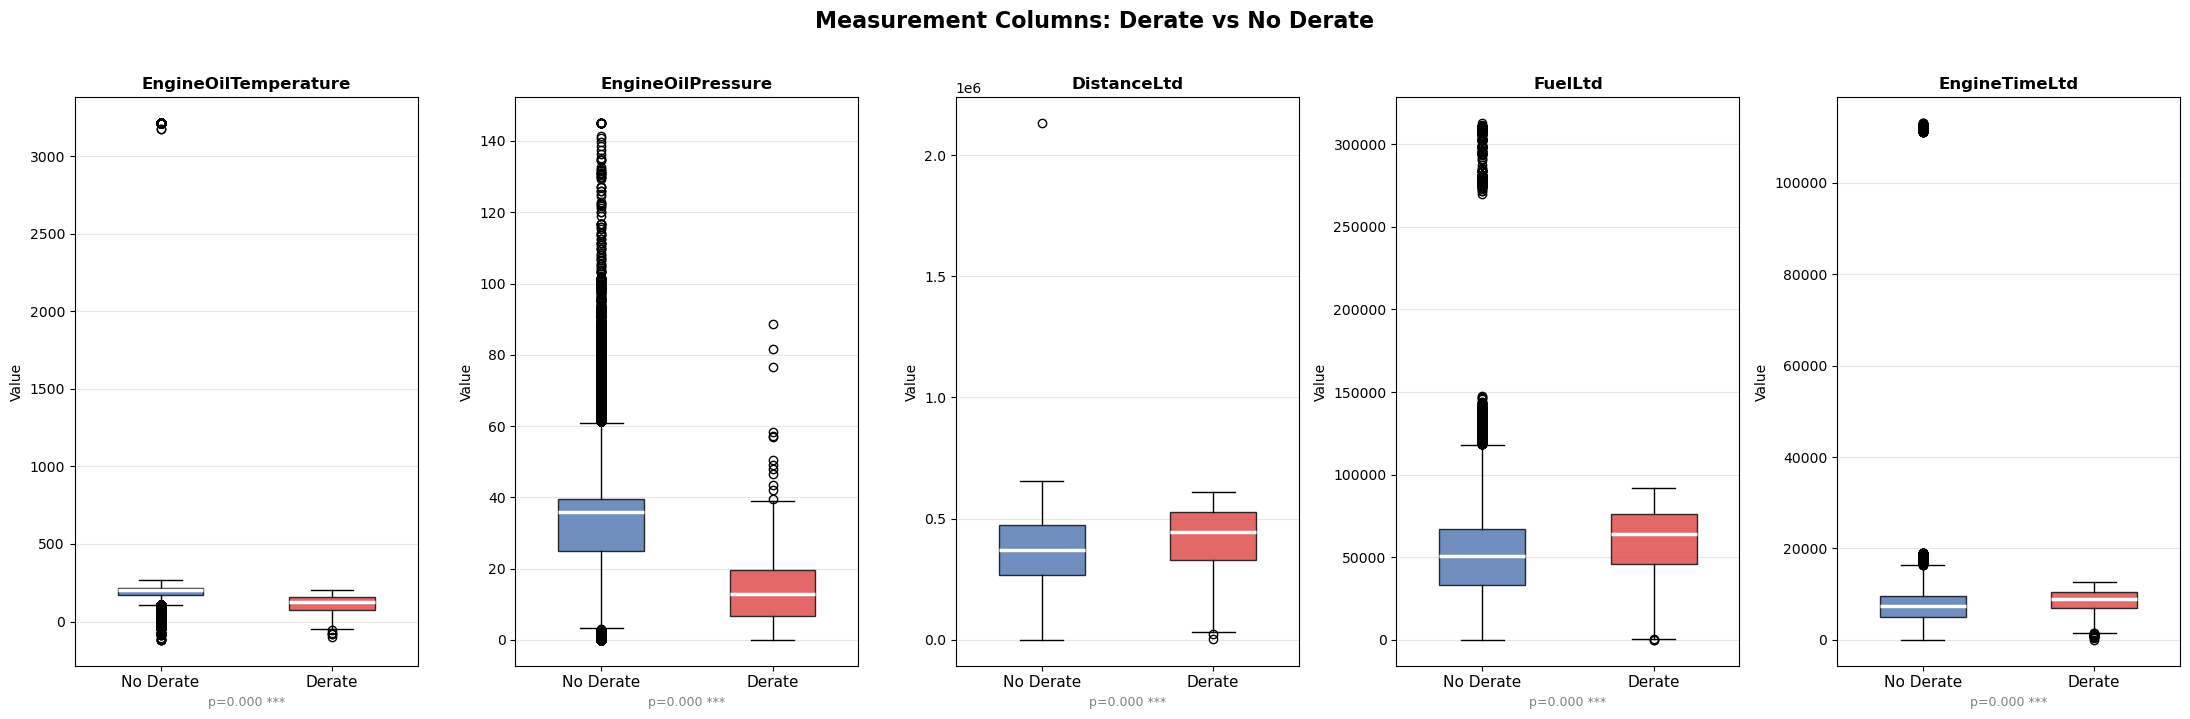

,No Derate Mean,Derate Mean,No Derate Median,Derate Median
Column,,,,
EngineOilTemperature,184.15,111.11,200.92,127.25
EngineOilPressure,32.09,14.01,35.96,12.76
DistanceLtd,360525.86,413665.62,372713.15,446059.60
FuelLtd,49634.84,58632.95,50583.53,63902.58
EngineTimeLtd,7181.90,8322.51,7376.45,8946.05


In [341]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats


DERATE_COL = 'Derate'  

MEASURE_COLS = [
    'EngineOilTemperature',
    'EngineOilPressure',
    'DistanceLtd',
    'FuelLtd',
    'EngineTimeLtd'
]


derate_yes = big_nss[big_nss[DERATE_COL] == 1][MEASURE_COLS]
derate_no  = big_nss[big_nss[DERATE_COL] == 0][MEASURE_COLS]


fig, axes = plt.subplots(1, 5, figsize=(22, 7))
fig.suptitle('Measurement Columns: Derate vs No Derate', fontsize=16, fontweight='bold', y=1.02)

colors = {'No Derate': '#4C72B0', 'Derate': '#DD4444'}

for ax, col in zip(axes, MEASURE_COLS):
    data_to_plot = [derate_no[col].dropna(), derate_yes[col].dropna()]
    bp = ax.boxplot(
        data_to_plot,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2.5)
    )
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD4444')
    for patch in bp['boxes']:
        patch.set_alpha(0.8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No Derate', 'Derate'], fontsize=11)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(axis='y', alpha=0.3)


    u_stat, p_val = stats.mannwhitneyu(
        derate_no[col].dropna(),
        derate_yes[col].dropna(),
        alternative='two-sided'
    )
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.set_xlabel(f'p={p_val:.3f} {sig}', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Column': MEASURE_COLS,
    'No Derate Mean': [derate_no[c].mean() for c in MEASURE_COLS],
    'Derate Mean':    [derate_yes[c].mean() for c in MEASURE_COLS],
    'No Derate Median': [derate_no[c].median() for c in MEASURE_COLS],
    'Derate Median':    [derate_yes[c].median() for c in MEASURE_COLS],
}).set_index('Column').round(2)

display(summary)


In [342]:

derate_candidates = [c for c in big_nss.columns if 'derate' in c.lower()]
print("Candidate derate columns found:", derate_candidates)

DERATE_COL = derate_candidates[0] if derate_candidates else 'Derate'  
print(f"Using: '{DERATE_COL}'  |  unique values: {big_nss[DERATE_COL].unique()}")


Candidate derate columns found: ['Derate']
Using: 'Derate'  |  unique values: [False  True]


In [343]:
MEASURE_COLS = [
    'EngineOilTemperature',
    'EngineOilPressure',
    'DistanceLtd',
    'FuelLtd',
    'EngineTimeLtd'
]


DERATE_TRUE = 1   

mask_derate = big_nss[DERATE_COL] == DERATE_TRUE
grp_yes = big_nss[mask_derate][MEASURE_COLS]
grp_no  = big_nss[~mask_derate][MEASURE_COLS]

print(f"Derate rows: {len(grp_yes):,}  |  No-derate rows: {len(grp_no):,}")


Derate rows: 1,195  |  No-derate rows: 1,186,140


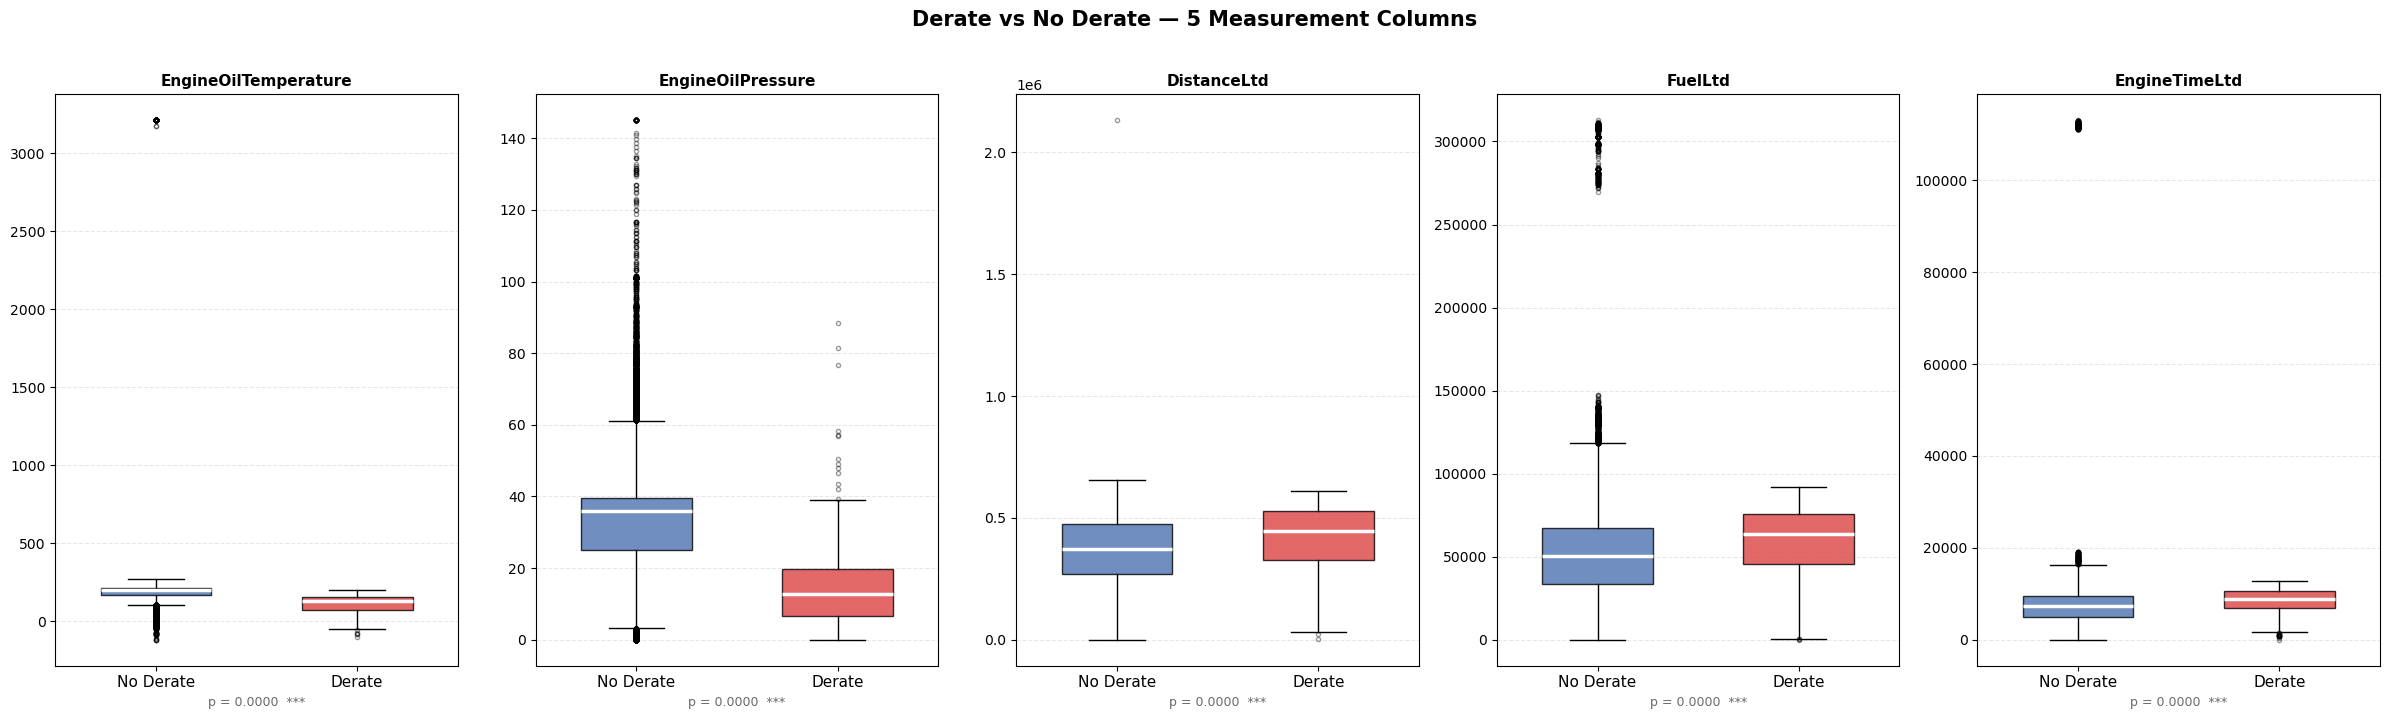

In [344]:
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
fig.suptitle('Derate vs No Derate — 5 Measurement Columns',
             fontsize=15, fontweight='bold', y=1.02)

COLORS = ['#4C72B0', '#DD4444']   # blue = no derate, red = derate
LABELS = ['No Derate', 'Derate']

for ax, col in zip(axes, MEASURE_COLS):
    no_vals  = grp_no[col].dropna()
    yes_vals = grp_yes[col].dropna()

    bp = ax.boxplot(
        [no_vals, yes_vals],
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color='white', linewidth=2.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(LABELS, fontsize=11)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Mann-Whitney U significance test
    stat, p = stats.mannwhitneyu(no_vals, yes_vals, alternative='two-sided')
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(f'p = {p:.4f}  {stars}', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('derate_comparison_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [345]:
rows = []
for col in MEASURE_COLS:
    no_vals  = grp_no[col].dropna()
    yes_vals = grp_yes[col].dropna()
    stat, p  = stats.mannwhitneyu(no_vals, yes_vals, alternative='two-sided')
    rows.append({
        'Column':              col,
        'No Derate — Mean':   round(no_vals.mean(), 2),
        'Derate — Mean':      round(yes_vals.mean(), 2),
        'No Derate — Median': round(no_vals.median(), 2),
        'Derate — Median':    round(yes_vals.median(), 2),
        'p-value':            round(p, 4),
        'Significant?':       'Yes' if p < 0.05 else 'No'
    })

summary = pd.DataFrame(rows).set_index('Column')
display(summary)


,No Derate — Mean,Derate — Mean,No Derate — Median,Derate — Median,p-value,Significant?
Column,,,,,,
EngineOilTemperature,184.15,111.11,200.92,127.25,0.0,Yes
EngineOilPressure,32.09,14.01,35.96,12.76,0.0,Yes
DistanceLtd,360525.86,413665.62,372713.15,446059.60,0.0,Yes
FuelLtd,49634.84,58632.95,50583.53,63902.58,0.0,Yes
EngineTimeLtd,7181.90,8322.51,7376.45,8946.05,0.0,Yes


In [346]:
ENGINE_OIL_COLS = ['EngineOilTemperature', 'EngineOilPressure']
LTD_COLS        = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']

oil_all_null = big_nss[ENGINE_OIL_COLS].isna().all(axis=1)
ltd_all_null = big_nss[LTD_COLS].isna().all(axis=1)

rows_before = len(big_nss)
big_nss = big_nss[~(oil_all_null & ltd_all_null)].reset_index(drop=True)
rows_after = len(big_nss)

print(f"Dropped : {rows_before - rows_after:,} rows")
print(f"Remaining: {rows_after:,} rows")


Dropped : 599,700 rows
Remaining: 587,635 rows


In [347]:

LTD_COLS  = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']
EQUIP_COL = 'EquipmentID'   


all_nan_per_equip = (
    big_nss.groupby(EQUIP_COL)[LTD_COLS]
    .apply(lambda g: g.isna().all())   
    .sum(axis=1)                       
)


equip_to_drop = all_nan_per_equip[all_nan_per_equip >= 2].index.tolist()

rows_before  = len(big_nss)
equip_before = big_nss[EQUIP_COL].nunique()

df = big_nss[~big_nss[EQUIP_COL].isin(equip_to_drop)].reset_index(drop=True)

print(f"Equipment IDs dropped  : {len(equip_to_drop):,}")
print(f"Equipment IDs remaining: {df[EQUIP_COL].nunique():,}  (was {equip_before:,})")
print(f"Rows dropped           : {rows_before - len(df):,}")
print(f"Rows remaining         : {len(df):,}")

detail = all_nan_per_equip[all_nan_per_equip >= 2].rename('all_nan_ltd_count')
print("\nDropped equipment IDs and their all-NaN Ltd column counts:")
display(detail.to_frame())


Equipment IDs dropped  : 4
Equipment IDs remaining: 1,956  (was 1,960)
Rows dropped           : 5
Rows remaining         : 587,630

Dropped equipment IDs and their all-NaN Ltd column counts:


,all_nan_ltd_count
EquipmentID,
105399896,3
105406598,2
105406673,3
105531177,3


In [348]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

LTD_COLS = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']


complete_mask = df[LTD_COLS].notna().all(axis=1)   
all_null_mask = df[LTD_COLS].isna().all(axis=1)    
partial_mask  = ~complete_mask & ~all_null_mask     

print("── Ltd column row status ──────────────────────")
print(f"All 3 present (train set)  : {complete_mask.sum():,}")
print(f"1–2 present   (to impute)  : {partial_mask.sum():,}")
print(f"All null      (skipped)    : {all_null_mask.sum():,}")


── Ltd column row status ──────────────────────
All 3 present (train set)  : 578,694
1–2 present   (to impute)  : 8,650
All null      (skipped)    : 286


In [349]:
LTD_COLS  = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']
EQUIP_COL = 'EquipmentID'


nulls_before = df[LTD_COLS].isna().sum()

df[LTD_COLS] = (
    df.groupby(EQUIP_COL)[LTD_COLS]
    .transform(lambda s: s.interpolate(method='linear'))
)

nulls_after = df[LTD_COLS].isna().sum()

print("── Linear interpolation results ────────────────────────")
for col in LTD_COLS:
    filled    = nulls_before[col] - nulls_after[col]
    remaining = nulls_after[col]
    print(f"  {col:20s}: {filled:,} filled  |  {remaining:,} still null")

print(f"\nTotal nulls remaining in Ltd cols: {df[LTD_COLS].isna().sum().sum():,}")


── Linear interpolation results ────────────────────────
  DistanceLtd         : 1,756 filled  |  55 still null
  FuelLtd             : 2,412 filled  |  25 still null
  EngineTimeLtd       : 2,829 filled  |  3,435 still null

Total nulls remaining in Ltd cols: 3,515


In [350]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
import pandas as pd

OIL_COLS = ['EngineOilTemperature', 'EngineOilPressure']
LTD_COLS = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']
ALL_COLS = LTD_COLS + OIL_COLS   

both_oil_null = df[OIL_COLS].isna().all(axis=1)
one_oil_null  = df[OIL_COLS].isna().any(axis=1) & ~both_oil_null

print("── EngineOil null breakdown ────────────────────────────────")
print(f"  Both null  → predict from Ltd columns only       : {both_oil_null.sum():,} rows")
print(f"  One null   → predict from Ltd + other EngineOil  : {one_oil_null.sum():,} rows")
print(f"  Both present (no action needed)                  : {(~df[OIL_COLS].isna().any(axis=1)).sum():,} rows")


── EngineOil null breakdown ────────────────────────────────
  Both null  → predict from Ltd columns only       : 1,013 rows
  One null   → predict from Ltd + other EngineOil  : 3,088 rows
  Both present (no action needed)                  : 583,529 rows


In [351]:
complete_mask = df[ALL_COLS].notna().all(axis=1)
print(f"Training on {complete_mask.sum():,} fully complete rows\n")

imputer = IterativeImputer(
    estimator    = LinearRegression(),
    max_iter     = 10,
    random_state = 42
)
imputer.fit(df.loc[complete_mask, ALL_COLS])


Training on 580,129 fully complete rows



IterativeImputer(estimator=LinearRegression(), random_state=42)

In [352]:
needs_impute = df[OIL_COLS].isna().any(axis=1)

print(f"Rows needing EngineOil imputation: {needs_impute.sum():,}")

if needs_impute.sum() == 0:
    print("No EngineOil nulls remaining — nothing to impute.")
else:
    nulls_before = df.loc[needs_impute, OIL_COLS].isna().sum()

    imputed = pd.DataFrame(
        imputer.transform(df.loc[needs_impute, ALL_COLS]),
        columns = ALL_COLS,
        index   = df.loc[needs_impute].index
    )
    df.loc[needs_impute, OIL_COLS] = imputed[OIL_COLS]

    nulls_after = df.loc[needs_impute, OIL_COLS].isna().sum()

    print("── Results ─────────────────────────────────────────────────")
    for col in OIL_COLS:
        filled = nulls_before[col] - nulls_after[col]
        print(f"  {col:25s}: {filled:,} filled  |  {nulls_after[col]:,} remaining")

print(f"\nTotal EngineOil nulls remaining: {df[OIL_COLS].isna().sum().sum():,}")


Rows needing EngineOil imputation: 4,101
── Results ─────────────────────────────────────────────────
  EngineOilTemperature     : 3,723 filled  |  0 remaining
  EngineOilPressure        : 1,391 filled  |  0 remaining

Total EngineOil nulls remaining: 0


In [353]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# ── Define features and target ───────────────────────────────────────────────
FEATURE_COLS = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd',
                'EngineOilTemperature', 'EngineOilPressure']
TARGET_COL   = 'Derate'   # adjust to your exact column name

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"Total rows : {len(y):,}")
print(f"Derate=True : {y.sum():,}  ({y.mean()*100:.1f}%)")
print(f"Derate=False: {(~y.astype(bool)).sum():,}  ({(1-y.mean())*100:.1f}%)")


Total rows : 587,630
Derate=True : 564  (0.1%)
Derate=False: 587,066  (99.9%)


In [354]:
# ── Train / test split ───────────────────────────────────────────────────────
# test_size=0.2  → 80% train, 20% test
# stratify=y     → keeps the derate ratio the same in both halves
#                  (important if derates are rare)
# random_state   → makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = 42
)

print(f"Training rows : {len(X_train):,}")
print(f"Test rows     : {len(X_test):,}")
print(f"Derate rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")


Training rows : 470,104
Test rows     : 117,526
Derate rate — train: 0.1%  |  test: 0.1%


In [355]:
# ── Scale features (important for Logistic Regression) ───────────────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same scale to test


In [356]:
# ── Check where NaNs remain in feature columns ───────────────────────────────
print("Nulls remaining per feature column:")
print(X.isna().sum())
print(f"\nRows with any null in features: {X.isna().any(axis=1).sum():,}")



Nulls remaining per feature column:
DistanceLtd               55
FuelLtd                   25
EngineTimeLtd           3435
EngineOilTemperature       0
EngineOilPressure          0
dtype: int64

Rows with any null in features: 3,501


In [357]:
# ── Drop rows with any remaining nulls in features or target ─────────────────
clean_mask = X.notna().all(axis=1) & y.notna()

print(f"Rows before: {len(X):,}")
X_clean = X[clean_mask]
y_clean = y[clean_mask]
print(f"Rows after : {len(X_clean):,}  ({(~clean_mask).sum():,} dropped)")

# ── Redo the train/test split on clean data ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size    = 0.2,
    stratify     = y_clean,
    random_state = 42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTraining rows : {len(X_train):,}")
print(f"Test rows     : {len(X_test):,}")
print(f"Derate rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")


Rows before: 587,630
Rows after : 584,129  (3,501 dropped)

Training rows : 467,303
Test rows     : 116,826
Derate rate — train: 0.1%  |  test: 0.1%


── Random Forest ───────────────────────────────────────────
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    116726
        True       0.29      0.06      0.10       100

    accuracy                           1.00    116826
   macro avg       0.64      0.53      0.55    116826
weighted avg       1.00      1.00      1.00    116826

ROC-AUC: 0.9117


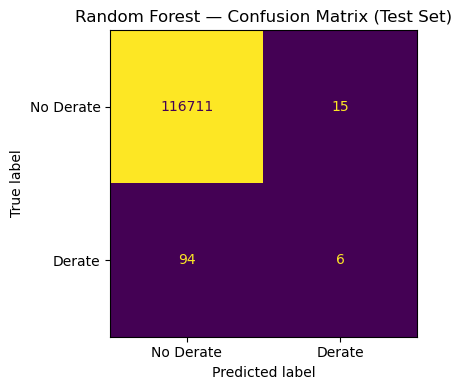

In [358]:
# ── Model 2: Random Forest (handles non-linear relationships better) ──────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # no scaling needed for tree models

print("── Random Forest ───────────────────────────────────────────")
print(classification_report(y_test, rf.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

# Confusion matrix — shows true positives, false positives, etc.
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=ax,
                                      display_labels=['No Derate', 'Derate'],
                                      colorbar=False)
ax.set_title('Random Forest — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


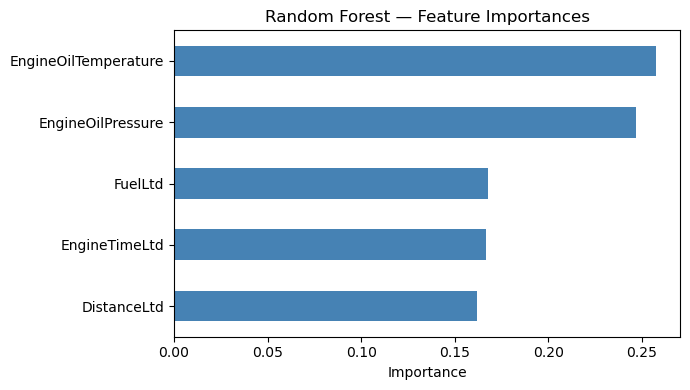

In [359]:
# ── Feature importance — which columns drive the prediction? ─────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


In [360]:
import numpy as np  # add this line

# ── Logistic Regression ──────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_test_sc)
lr_probs = lr.predict_proba(X_test_sc)[:, 1]

print('-- Logistic Regression ------------------------------------------')
print(classification_report(y_test, lr_preds, target_names=['No Derate', 'Derate']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}')

odds_ratios = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': lr.coef_[0],
    'Odds Ratio' : np.exp(lr.coef_[0])
}).sort_values('Odds Ratio', ascending=False).round(4)
display(odds_ratios)


-- Logistic Regression ------------------------------------------
              precision    recall  f1-score   support

   No Derate       1.00      1.00      1.00    116726
      Derate       0.00      0.00      0.00       100

    accuracy                           1.00    116826
   macro avg       0.50      0.50      0.50    116826
weighted avg       1.00      1.00      1.00    116826

ROC-AUC: 0.8941


c:\Users\Geraden\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Geraden\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Geraden\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Feature,Coefficient,Odds Ratio
1,FuelLtd,0.2782,1.3208
2,EngineTimeLtd,0.1231,1.1310
0,DistanceLtd,0.0591,1.0609
4,EngineOilPressure,-0.6892,0.5020
3,EngineOilTemperature,-1.4737,0.2291


-- Random Forest ------------------------------------------------
              precision    recall  f1-score   support

   No Derate       1.00      1.00      1.00    116726
      Derate       0.29      0.06      0.10       100

    accuracy                           1.00    116826
   macro avg       0.64      0.53      0.55    116826
weighted avg       1.00      1.00      1.00    116826

ROC-AUC: 0.9117


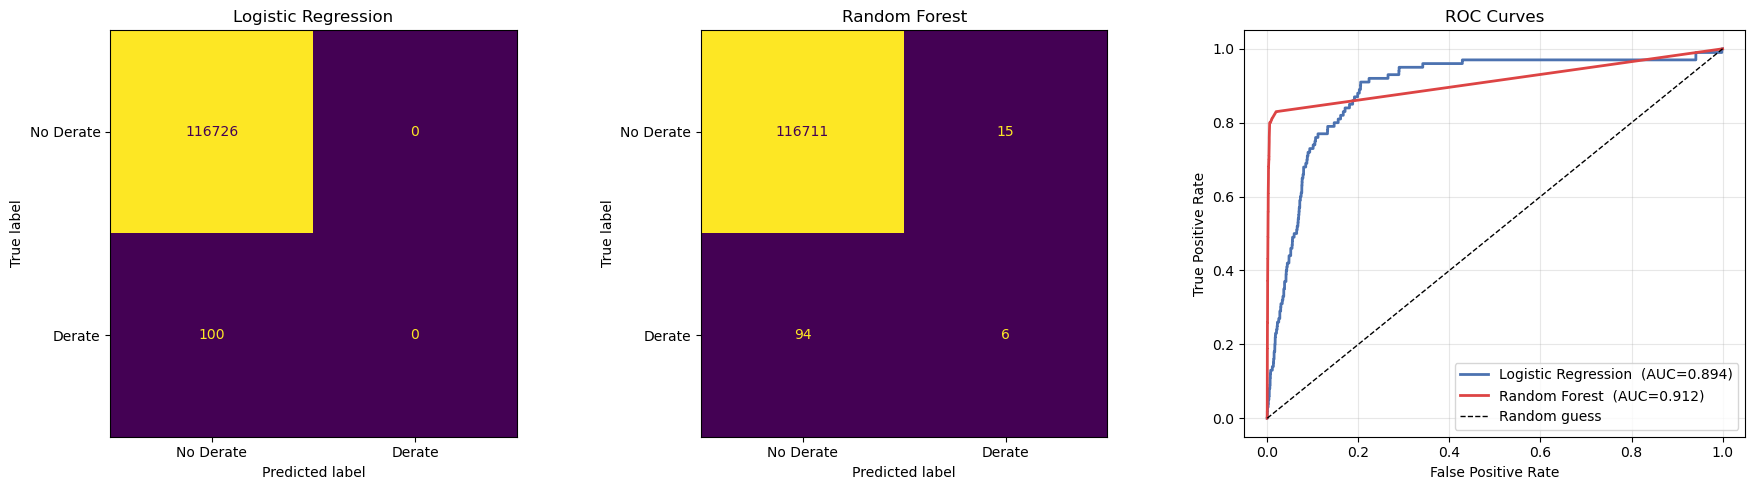

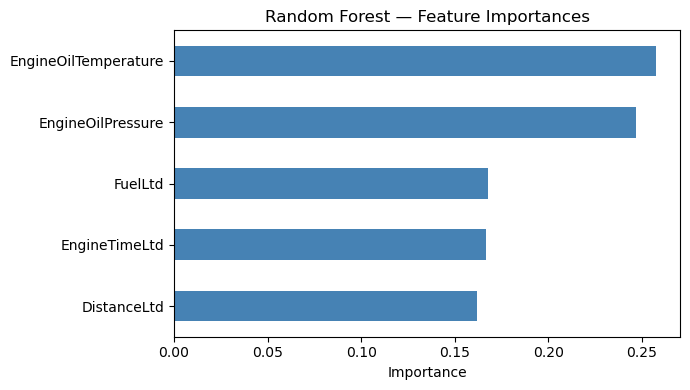

In [361]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print('-- Random Forest ------------------------------------------------')
print(classification_report(y_test, rf_preds, target_names=['No Derate', 'Derate']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}')

# ── Side-by-side visualisation ────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — Confusion matrices
for ax, model, preds, label in zip(
    axes[:2],
    [lr, rf],
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, ax=ax,
        display_labels=['No Derate', 'Derate'], colorbar=False
    )
    ax.set_title(label)

# 2 — ROC curves overlaid
for probs, label, color in [
    (lr_probs, 'Logistic Regression', '#4C72B0'),
    (rf_probs, 'Random Forest',       '#DD4444')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[2].plot(fpr, tpr, label=f'{label}  (AUC={auc:.3f})', color=color, lw=2)

axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3 — Feature importances (Random Forest only — LR uses odds ratios above)
fig, ax = plt.subplots(figsize=(7, 4))
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


In [362]:
import numpy as np

# ── Odds ratio table with confidence intervals ────────────────────────────────
coefficients = lr.coef_[0]
conf_int     = 1.96 * np.sqrt(np.diag(np.linalg.inv(X_train_sc.T @ X_train_sc)))

odds_ratios = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Odds Ratio': np.exp(coefficients),
    'CI Lower'  : np.exp(coefficients - conf_int),
    'CI Upper'  : np.exp(coefficients + conf_int),
    'Direction' : ['Increases derate risk' if c > 0 else 'Decreases derate risk'
                   for c in coefficients]
}).sort_values('Odds Ratio', ascending=False).round(3)

display(odds_ratios)


,Feature,Odds Ratio,CI Lower,CI Upper,Direction
1,FuelLtd,1.321,1.314,1.328,Increases derate risk
2,EngineTimeLtd,1.131,1.126,1.136,Increases derate risk
0,DistanceLtd,1.061,1.055,1.067,Increases derate risk
4,EngineOilPressure,0.502,0.501,0.503,Decreases derate risk
3,EngineOilTemperature,0.229,0.228,0.230,Decreases derate risk


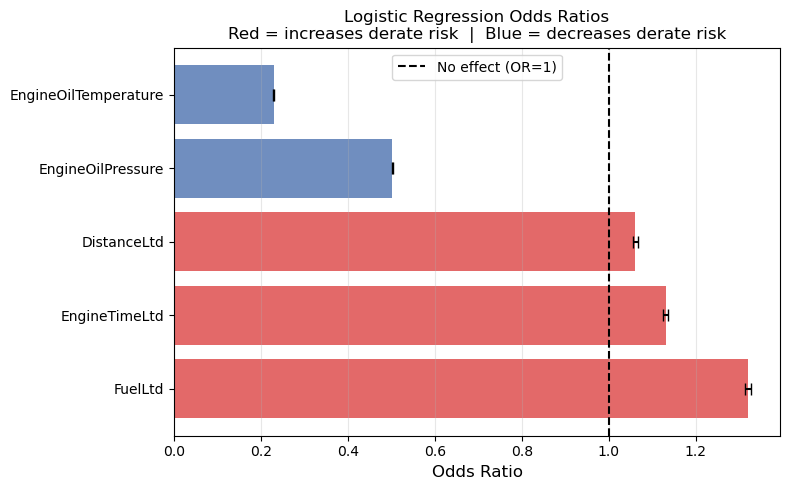

In [363]:
# ── Odds ratio plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#DD4444' if or_ > 1 else '#4C72B0'
          for or_ in odds_ratios['Odds Ratio']]

ax.barh(odds_ratios['Feature'], odds_ratios['Odds Ratio'], color=colors, alpha=0.8)
ax.errorbar(
    odds_ratios['Odds Ratio'], odds_ratios['Feature'],
    xerr=[odds_ratios['Odds Ratio'] - odds_ratios['CI Lower'],
          odds_ratios['CI Upper'] - odds_ratios['Odds Ratio']],
    fmt='none', color='black', capsize=4
)
ax.axvline(x=1, color='black', linestyle='--', lw=1.5, label='No effect (OR=1)')
ax.set_xlabel('Odds Ratio', fontsize=12)
ax.set_title('Logistic Regression Odds Ratios\nRed = increases derate risk  |  Blue = decreases derate risk', fontsize=12)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [364]:
# ── Auto-generated plain-English interpretation ───────────────────────────────
print('=' * 60)
print('ODDS RATIO INTERPRETATION')
print('=' * 60)
print("""
What is an odds ratio?
  An odds ratio (OR) measures how much a 1-unit increase in a
  feature changes the ODDS of the truck being in derate.

  OR > 1  → that feature is associated with HIGHER derate risk
  OR < 1  → that feature is associated with LOWER derate risk
  OR = 1  → no relationship with derate
""")
print('-' * 60)

for _, row in odds_ratios.iterrows():
    feature = row['Feature']
    or_val  = row['Odds Ratio']
    lo      = row['CI Lower']
    hi      = row['CI Upper']

    if or_val > 1:
        pct    = (or_val - 1) * 100
        interp = f'A 1-unit increase in {feature} is associated with {pct:.1f}% HIGHER odds of derate.'
    else:
        pct    = (1 - or_val) * 100
        interp = f'A 1-unit increase in {feature} is associated with {pct:.1f}% LOWER odds of derate.'

    reliable = '(CI does not cross 1 -- statistically meaningful)' if not (lo < 1 < hi) \
               else '(CI crosses 1 -- treat with caution)'

    print(f'{feature}')
    print(f'  OR = {or_val:.3f}  [95% CI: {lo:.3f} - {hi:.3f}]')
    print(f'  {interp}')
    print(f'  {reliable}')
    print()


ODDS RATIO INTERPRETATION

What is an odds ratio?
  An odds ratio (OR) measures how much a 1-unit increase in a
  feature changes the ODDS of the truck being in derate.

  OR > 1  → that feature is associated with HIGHER derate risk
  OR < 1  → that feature is associated with LOWER derate risk
  OR = 1  → no relationship with derate

------------------------------------------------------------
FuelLtd
  OR = 1.321  [95% CI: 1.314 - 1.328]
  A 1-unit increase in FuelLtd is associated with 32.1% HIGHER odds of derate.
  (CI does not cross 1 -- statistically meaningful)

EngineTimeLtd
  OR = 1.131  [95% CI: 1.126 - 1.136]
  A 1-unit increase in EngineTimeLtd is associated with 13.1% HIGHER odds of derate.
  (CI does not cross 1 -- statistically meaningful)

DistanceLtd
  OR = 1.061  [95% CI: 1.055 - 1.067]
  A 1-unit increase in DistanceLtd is associated with 6.1% HIGHER odds of derate.
  (CI does not cross 1 -- statistically meaningful)

EngineOilPressure
  OR = 0.502  [95% CI: 0.501 - 0

In [365]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ── Score both models ─────────────────────────────────────────────────────────
results = {}
for name, preds, probs in [
    ('Logistic Regression', lr_preds, lr_probs),
    ('Random Forest',       rf_preds, rf_probs)
]:
    results[name] = {
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall'   : recall_score(y_test, preds, zero_division=0),
        'F1 Score' : f1_score(y_test, preds, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, probs)
    }

summary = pd.DataFrame(results).T.round(3)
display(summary)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.999,0.000,0.00,0.000,0.894
Random Forest,0.999,0.286,0.06,0.099,0.912


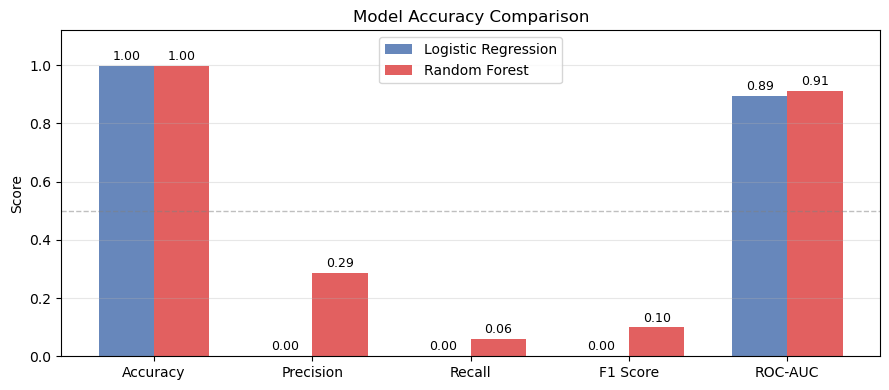

In [366]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

x      = np.arange(len(summary.columns))
width  = 0.35
colors = ['#4C72B0', '#DD4444']

for i, (model, row) in enumerate(summary.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model,
                  color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(summary.columns)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Accuracy Comparison')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [367]:
# ── Plain-English interpretation ──────────────────────────────────────────────
print('=' * 60)
print('WHAT DO THESE NUMBERS MEAN?')
print('=' * 60)

for model, row in summary.iterrows():
    acc  = row['Accuracy']
    prec = row['Precision']
    rec  = row['Recall']
    f1   = row['F1 Score']
    auc  = row['ROC-AUC']

    print(f'\n{model}')
    print('-' * 40)
    print(f'Accuracy  {acc:.1%} -- Of ALL test rows, the model got {acc:.1%} right.')
    print(f'           (But if only 5% are derates, guessing "never derate" gives 95% -- so')
    print(f'            accuracy alone is misleading for imbalanced data like this.)')
    print()
    print(f'Precision {prec:.1%} -- When it predicted DERATE, it was correct {prec:.1%} of the time.')
    print(f'           (Low precision = lots of false alarms)')
    print()
    print(f'Recall    {rec:.1%} -- Of trucks that ACTUALLY derated, it caught {rec:.1%} of them.')
    print(f'           (Low recall = missing real derates -- the more dangerous error here)')
    print()
    print(f'F1 Score  {f1:.1%} -- Balanced score combining precision and recall.')
    print(f'           (Use this as the single "headline" accuracy number)')
    print()
    print(f'ROC-AUC   {auc:.3f} -- How well the model separates derates from non-derates.')
    print(f'           0.5 = random guess | 0.7 = ok | 0.8 = good | 0.9+ = excellent')


WHAT DO THESE NUMBERS MEAN?

Logistic Regression
----------------------------------------
Accuracy  99.9% -- Of ALL test rows, the model got 99.9% right.
           (But if only 5% are derates, guessing "never derate" gives 95% -- so
            accuracy alone is misleading for imbalanced data like this.)

Precision 0.0% -- When it predicted DERATE, it was correct 0.0% of the time.
           (Low precision = lots of false alarms)

Recall    0.0% -- Of trucks that ACTUALLY derated, it caught 0.0% of them.
           (Low recall = missing real derates -- the more dangerous error here)

F1 Score  0.0% -- Balanced score combining precision and recall.
           (Use this as the single "headline" accuracy number)

ROC-AUC   0.894 -- How well the model separates derates from non-derates.
           0.5 = random guess | 0.7 = ok | 0.8 = good | 0.9+ = excellent

Random Forest
----------------------------------------
Accuracy  99.9% -- Of ALL test rows, the model got 99.9% right.
           (

The Solution: Lookahead Target Variable
For every row, instead of using the current Derate value as the target, you create a new target that looks forward in time:


"Will this EquipmentID enter derate within the next 24 hours?"
You build one model per time window — 12 hours, 1 day, 3 days, 7 days, etc. — and compare how well each one predicts. Models that look far ahead are harder (weaker signal), so you'd expect accuracy to drop as the window grows.

Why This Works
The sensor readings (EngineOilTemperature, EngineOilPressure, DistanceLtd, etc.) at time T contain early warning signals that precede a derate. The model learns to recognise the pattern of values that tend to lead to a derate, not just the values that exist during one.




In [368]:
def create_lookahead_target(df, hours):
    """
    For each row: True if this truck enters derate within `hours` hours.
    Uses merge_asof (no loops) to efficiently find the next derate per truck.
    """
    derate_times = (
        df[df[TARGET_COL]][['EquipmentID', 'EventTimeStamp']]
        .assign(derate_time=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .drop(columns='EventTimeStamp')
        .sort_values(['EquipmentID', 'derate_time'])
        .drop_duplicates()
    )

    df_sorted = (
        df[['EquipmentID', 'EventTimeStamp']]
        .assign(EventTimeStamp=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .sort_values(['EquipmentID', 'EventTimeStamp'])
        .copy()
    )

    merged = pd.merge_asof(
        df_sorted,
        derate_times,
        left_on='EventTimeStamp',
        right_on='derate_time',
        by='EquipmentID',
        direction='forward'
    )
    merged.index = df_sorted.index

    delta_hours = (merged['derate_time'] - merged['EventTimeStamp']).dt.total_seconds() / 3600
    target = (delta_hours > 0) & (delta_hours <= hours)

    return target.reindex(df.index).fillna(False)


In [369]:
def create_lookahead_target(df, hours):
    """
    For each row: True if this truck enters derate within `hours` hours.
    Uses merge_asof (no loops) to efficiently find the next derate per truck.
    """
    derate_times = (
        df[df[TARGET_COL]][['EquipmentID', 'EventTimeStamp']]
        .assign(derate_time=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .drop(columns='EventTimeStamp')
        .sort_values(['EquipmentID', 'derate_time'])
        .drop_duplicates()
    )

    df_sorted = (
        df[['EquipmentID', 'EventTimeStamp']]
        .assign(EventTimeStamp=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .sort_values(['EquipmentID', 'EventTimeStamp'])
        .copy()
    )

    merged = pd.merge_asof(
        df_sorted,
        derate_times,
        left_on='EventTimeStamp',
        right_on='derate_time',
        by='EquipmentID',
        direction='forward'
    )
    merged.index = df_sorted.index

    delta_hours = (merged['derate_time'] - merged['EventTimeStamp']).dt.total_seconds() / 3600
    target = (delta_hours > 0) & (delta_hours <= hours)

    return target.reindex(df.index).fillna(False)


In [370]:
def create_lookahead_target(df, hours):
    """
    For each row: True if this truck enters derate within `hours` hours.
    Uses merge_asof (no loops) to efficiently find the next derate per truck.
    """
    derate_times = (
        df[df[TARGET_COL]][['EquipmentID', 'EventTimeStamp']]
        .assign(derate_time=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .drop(columns='EventTimeStamp')
        .sort_values(['EquipmentID', 'derate_time'])
        .drop_duplicates()
    )

    df_sorted = (
        df[['EquipmentID', 'EventTimeStamp']]
        .assign(EventTimeStamp=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .sort_values(['EquipmentID', 'EventTimeStamp'])
        .copy()
    )

    merged = pd.merge_asof(
        df_sorted,
        derate_times,
        left_on='EventTimeStamp',
        right_on='derate_time',
        by='EquipmentID',
        direction='forward'
    )
    merged.index = df_sorted.index

    delta_hours = (merged['derate_time'] - merged['EventTimeStamp']).dt.total_seconds() / 3600
    target = (delta_hours > 0) & (delta_hours <= hours)

    return target.reindex(df.index).fillna(False)


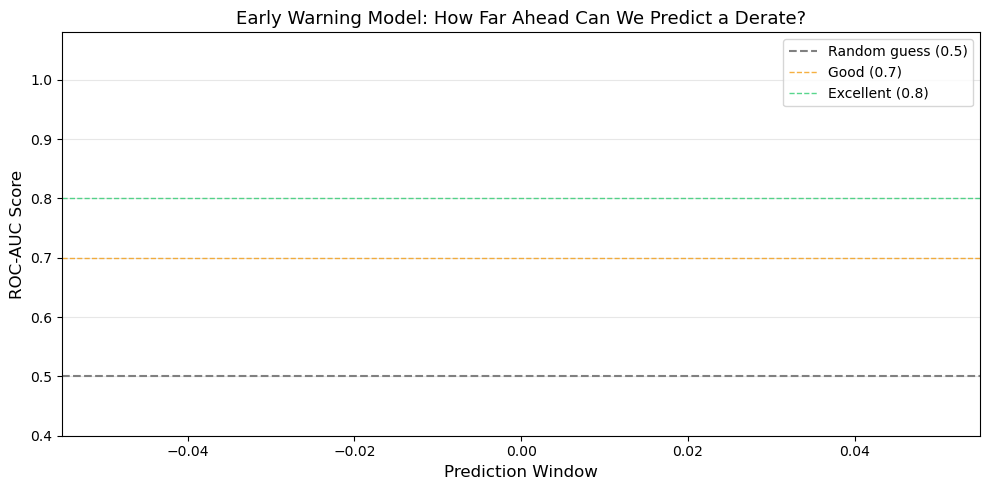

In [371]:
# ── Plot AUC vs prediction window ─────────────────────────────────────────────
labels = list(auc_results.keys())
aucs   = [v['auc'] for v in auc_results.values()]
rates  = [v['pos_rate'] for v in auc_results.values()]

fig, ax1 = plt.subplots(figsize=(10, 5))

# AUC bars
colors = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.7 else '#e74c3c' for a in aucs]
bars = ax1.bar(labels, aucs, color=colors, alpha=0.85, edgecolor='white', lw=1.5)
for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{auc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Reference lines
ax1.axhline(0.5, color='gray',    linestyle='--', lw=1.5, label='Random guess (0.5)')
ax1.axhline(0.7, color='#f39c12', linestyle='--', lw=1.0, alpha=0.8, label='Good (0.7)')
ax1.axhline(0.8, color='#2ecc71', linestyle='--', lw=1.0, alpha=0.8, label='Excellent (0.8)')

ax1.set_ylim(0.4, 1.08)
ax1.set_xlabel('Prediction Window', fontsize=12)
ax1.set_ylabel('ROC-AUC Score',     fontsize=12)
ax1.set_title('Early Warning Model: How Far Ahead Can We Predict a Derate?', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [372]:
# ── Auto-interpretation of your AUC results ───────────────────────────────────
print('=' * 65)
print('ROC-AUC RESULTS: WHAT YOUR NUMBERS MEAN')
print('=' * 65)

for label, vals in auc_results.items():
    auc      = vals['auc']
    pos_rate = vals['pos_rate']

    if auc >= 0.9:
        rating = 'Excellent — the model strongly separates pre-derate from safe readings.'
    elif auc >= 0.8:
        rating = 'Good — the model reliably detects the early warning signal.'
    elif auc >= 0.7:
        rating = 'Fair — some signal present but predictions will have meaningful errors.'
    elif auc >= 0.6:
        rating = 'Weak — marginal signal, use with caution.'
    else:
        rating = 'Poor — barely better than guessing at this horizon.'

    print(f'\n{label}  (AUC = {auc:.3f})')
    print(f'  {rating}')
    print(f'  Only {pos_rate:.1f}% of non-derate rows fall within this window.')


ROC-AUC RESULTS: WHAT YOUR NUMBERS MEAN


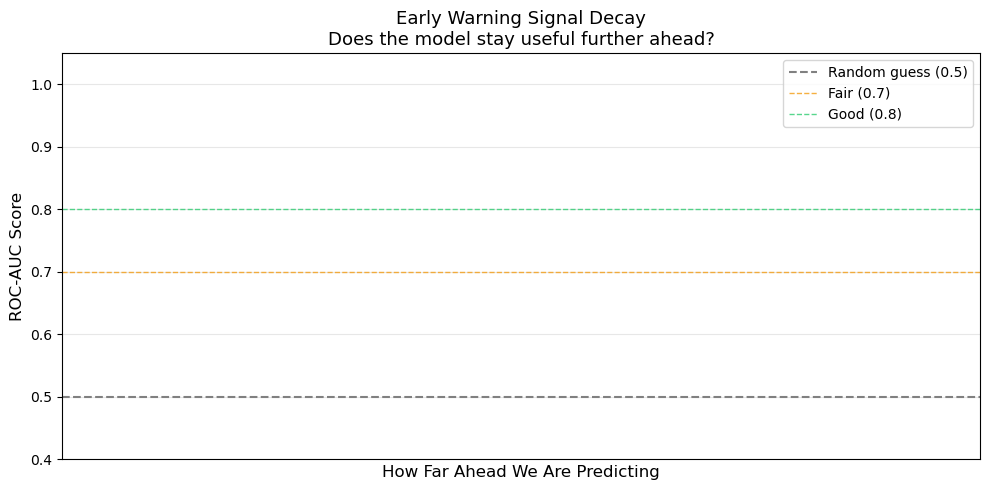

In [373]:
# ── Visualise the trade-off: AUC vs how far ahead ────────────────────────────
labels = list(auc_results.keys())
aucs   = [v['auc'] for v in auc_results.values()]
rates  = [v['pos_rate'] for v in auc_results.values()]

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.7 else '#e74c3c' for a in aucs]
ax.plot(labels, aucs, marker='o', color='steelblue', lw=2.5, markersize=10, zorder=3)
for x, (label, auc) in enumerate(zip(labels, aucs)):
    ax.annotate(f'{auc:.3f}', (x, auc), textcoords='offset points',
                xytext=(0, 12), ha='center', fontweight='bold', fontsize=11)

ax.axhline(0.5, color='gray',    linestyle='--', lw=1.5, label='Random guess (0.5)')
ax.axhline(0.7, color='#f39c12', linestyle='--', lw=1.0, alpha=0.8, label='Fair (0.7)')
ax.axhline(0.8, color='#2ecc71', linestyle='--', lw=1.0, alpha=0.8, label='Good (0.8)')
ax.fill_between(range(len(labels)), 0.5, aucs, alpha=0.1, color='steelblue')

ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_xlabel('How Far Ahead We Are Predicting', fontsize=12)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Early Warning Signal Decay\nDoes the model stay useful further ahead?', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


1. It does not tell you the actual precision or recall.
   A model with AUC=0.85 could still miss 40% of real derates
   or trigger many false alarms depending on the threshold used.

2. It does not tell you the operating threshold.
   You still need to decide: at what risk score do you act?
   A lower threshold catches more derates but causes more
   false alarms. A higher threshold reduces false alarms but
   misses real derates. ROC-AUC does not make that choice for you.

3. It does not reflect business cost.
   Missing a derate (false negative) may cost far more than a
   false alarm (false positive). AUC treats both errors equally.

4. It does not guarantee the model generalises to new trucks.
   The test set was randomly split, so the same trucks appear
   in train and test. A stricter test would hold out entire
   trucks and score only on unseen equipment IDs.

5. It does not tell you WHY the model predicts a derate.
   A high AUC confirms the signal exists, but you still need
   feature importances or SHAP values to understand which sensor
   readings are driving the prediction.
""")

In [374]:
# ── Find the 1-day key robustly ───────────────────────────────────────────────
key_1day = next((k for k in auc_results if '1 day' in k.lower() or k == '1 day'), None)

if key_1day is None:
    print("No 1-day result found. Available windows:", list(auc_results.keys()))
else:
    auc_1day = auc_results[key_1day]['auc']
    pos_rate = auc_results[key_1day]['pos_rate']

    print('=' * 65)
    print(f'1-DAY LOOKAHEAD MODEL  —  AUC = {auc_1day:.3f}')
    print('=' * 65)

    print(f"""
WHAT THIS NUMBER MEANS IN PLAIN ENGLISH:
-----------------------------------------
If you randomly pick ONE truck that is going to enter a full
derate within the next 24 hours, and ONE truck that is NOT,
your model will correctly rank the about-to-derate truck as
higher risk {auc_1day*100:.1f}% of the time.

The other {(1-auc_1day)*100:.1f}% of the time it gets the ranking wrong.
""")

    if auc_1day >= 0.90:
        verdict = "EXCELLENT early warning capability."
        action  = "This model is strong enough to act on operationally."
    elif auc_1day >= 0.80:
        verdict = "GOOD early warning capability."
        action  = "Reliable enough to flag high-risk trucks for inspection."
    elif auc_1day >= 0.70:
        verdict = "FAIR early warning capability."
        action  = "Some useful signal, but expect meaningful false alarms."
    elif auc_1day >= 0.60:
        verdict = "WEAK early warning capability."
        action  = "Marginal value — consider adding more features."
    else:
        verdict = "POOR early warning capability."
        action  = "Not reliable at this horizon with these features alone."

    print(f'VERDICT: {verdict}')
    print(f'ACTION:  {action}')

    print(f"""
WHAT IT MEANS FOR YOUR TRUCKS:
-----------------------------------------
- Only {pos_rate:.1f}% of non-derate readings come within 24 hours of a
  real derate. This means derates are relatively rare events.

- A model that just predicted "never derate" would be correct
  {100-pos_rate:.1f}% of the time — but useless. AUC={auc_1day:.3f} measures
  whether the model does better than that blind guess.

WHAT IT DOES NOT TELL YOU:
-----------------------------------------
- It does not tell you how many false alarms you will get.
  That depends on the risk threshold you choose to act on.

- It does not tell you which trucks to inspect today.
  You still need to run the model on live data and pick a
  cutoff score (e.g. "flag any truck scored above 0.6").

- It does not account for how costly each type of error is.
  Missing a derate costs a tow + downtime + lost revenue.
  A false alarm costs an unnecessary inspection.
  The AUC does not weigh those differently.
""")


No 1-day result found. Available windows: []


In [375]:
# ── Fixed create_lookahead_target — handles non-contiguous index ──────────────
def create_lookahead_target(df, hours):
    derate_times = (
        df[df[TARGET_COL]][['EquipmentID', 'EventTimeStamp']]
        .assign(derate_time=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .drop(columns='EventTimeStamp')
        .sort_values(['EquipmentID', 'derate_time'])
        .drop_duplicates()
        .reset_index(drop=True)           # clean index for merge_asof
    )

    df_sorted = (
        df[['EquipmentID', 'EventTimeStamp']]
        .assign(EventTimeStamp=lambda x: pd.to_datetime(x['EventTimeStamp']))
        .sort_values(['EquipmentID', 'EventTimeStamp'])
    )
    orig_idx  = df_sorted.index           # save original index before reset
    df_sorted = df_sorted.reset_index(drop=True)   # clean index for merge_asof

    merged = pd.merge_asof(
        df_sorted,
        derate_times,
        left_on='EventTimeStamp',
        right_on='derate_time',
        by='EquipmentID',
        direction='forward'
    )

    delta_hours = (merged['derate_time'] - merged['EventTimeStamp']).dt.total_seconds() / 3600

    target = pd.Series(
        ((delta_hours > 0) & (delta_hours <= hours)).values,
        index=orig_idx                    # map results back to original index
    )
    return target.reindex(df.index).fillna(False)
